In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

In [4]:
df = pd.read_csv(r'D:\MLproject\Notebook\data\StudentsPerformance.csv')

In [5]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


DATA CHECK PERFORMANCE
1. Missing Values
2. Duplicate Values
3. Data Type
4. The number of unique values of each column
5. statistics of data set
6. check various catagories present in catagorial columns

In [6]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [9]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [10]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [17]:
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


Exploring Data

In [18]:
print("categories in 'gender' variable: ",end=" ")
print(df['gender'].unique())

print("categories in 'race/ethnicity' variable: ",end=" ")
print(df['race/ethnicity'].unique())

print("categories in 'parental level of education' variable: ",end=" ")
print(df['parental level of education'].unique())

print("categories in 'lunch' variable: ",end=" ")
print(df['lunch'].unique())

print("categories in 'test preparation course' variable: ",end=" ")
print(df['test preparation course'].unique())

categories in 'gender' variable:  ['female' 'male']
categories in 'race/ethnicity' variable:  ['group B' 'group C' 'group A' 'group D' 'group E']
categories in 'parental level of education' variable:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
categories in 'lunch' variable:  ['standard' 'free/reduced']
categories in 'test preparation course' variable:  ['none' 'completed']


In [11]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [20]:
# categorical feaatures and numerical features
numeric_features = [feature for feature in df.columns if df[feature].dtype !='O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features :{}'. format(len(numeric_features),numeric_features))
print('\nwe have {} categorical features :{}'.format(len(categorical_features),categorical_features))

We have 3 numerical features :['math score', 'reading score', 'writing score']

we have 5 categorical features :['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


Adding all the scores and average the scores

In [21]:
df['total_score'] = df['reading score'] + df['writing score'] + df['math score']
df['Avg'] = df['total_score']/3

In [22]:
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,Avg
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


In [24]:
reading_full = df[df['reading score']==100]['Avg'].count()
writting_full = df[df['writing score']==100]['Avg'].count()
math_full = df[df['math score']==100]['Avg'].count()
print(f'math: {math_full}')
print(f'reading: {reading_full}')
print(f'writting: {writting_full}')

math: 7
reading: 17
writting: 14


In [25]:
reading_less_20 = df[df['reading score']<= 20]['Avg'].count()
writting_less_20 = df[df['writing score']<=20]['Avg'].count()
math_less_20 = df[df['math score']<=20]['Avg'].count()
print(f'math: {math_less_20}')
print(f'reading: {reading_less_20}')
print(f'writting: {writting_less_20}')

math: 4
reading: 1
writting: 3


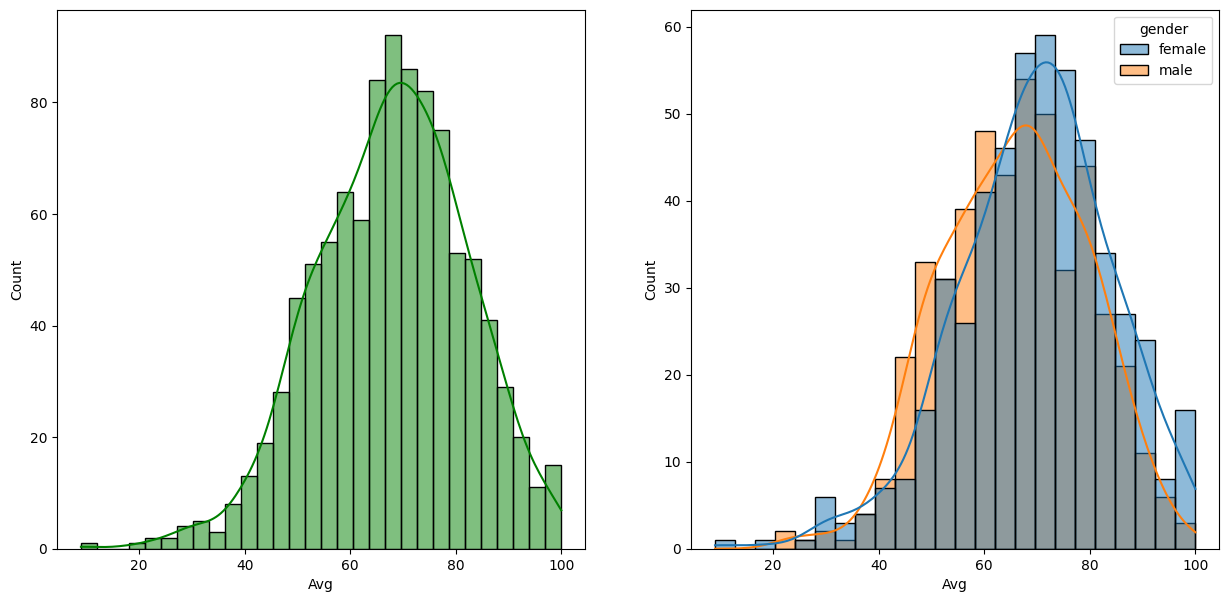

In [32]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='Avg',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Avg',kde=True,hue='gender')
plt.show()

C:\Users\B.Jagadeesh\AppData\Local\Temp\ipykernel_19436\523141675.py:2: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(141)
C:\Users\B.Jagadeesh\AppData\Local\Temp\ipykernel_19436\523141675.py:4: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(142)
C:\Users\B.Jagadeesh\AppData\Local\Temp\ipykernel_19436\523141675.py:6: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(143)


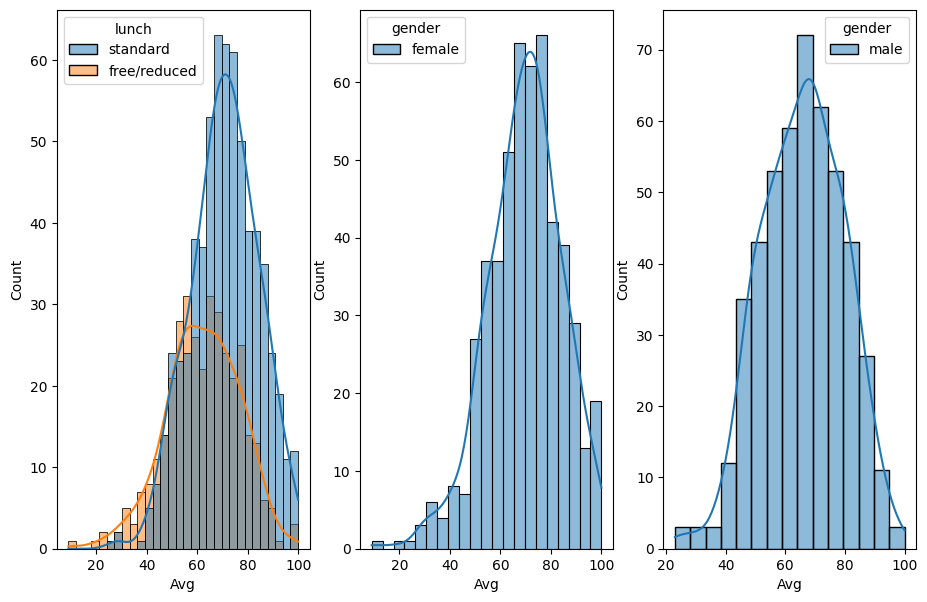

In [33]:
fig, axs = plt.subplots(1, 3, figsize=(15, 7))
plt.subplot(141)
sns.histplot(data=df,x='Avg',bins=30,kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='Avg',kde=True,hue='gender')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='Avg',kde=True,hue='gender')
plt.show()